In [12]:
# Working example of HCIpy

# Working Example of HCIpy

In [31]:
import hcipy
from hcipy import Field, Wavefront, make_pupil_grid, make_focal_grid, FraunhoferPropagator
import numpy as np
import matplotlib.pyplot as plt



In [32]:
# Set preferred matplotlib style
# Make cycle colorblind friendly 
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=plt.cm.tab10.colors)
def set_iraf_aas_style():
    """
    IRAF/AAS-inspired plotting style:
    serif fonts, inward ticks, clean axes, minimal grid.
    """
    plt.rcParams.update({
        # Fonts
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "dejavuserif",

        # Figure/export
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.format": "pdf",

        # Axes
        "axes.linewidth": 1.1,
        "axes.labelsize": 12,
        "axes.titlesize": 12,

        # Ticks
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "xtick.major.size": 5.5,
        "ytick.major.size": 5.5,
        "xtick.minor.size": 3.0,
        "ytick.minor.size": 3.0,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "xtick.minor.width": 0.8,
        "ytick.minor.width": 0.8,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,

        # Legend
        "legend.frameon": False,
        "legend.loc": "best",
        "legend.framealpha": 1.0,
        "legend.fontsize": 10,

        # Error bars
        "errorbar.capsize": 2.5,
        "lines.linewidth": 1.2,
    })

set_iraf_aas_style()

## Grids

The first concept we encounter is a grid -- it is what you think it is: regularly spaced N x N points in cartesian space. 

Text(0, 0.5, 'y')

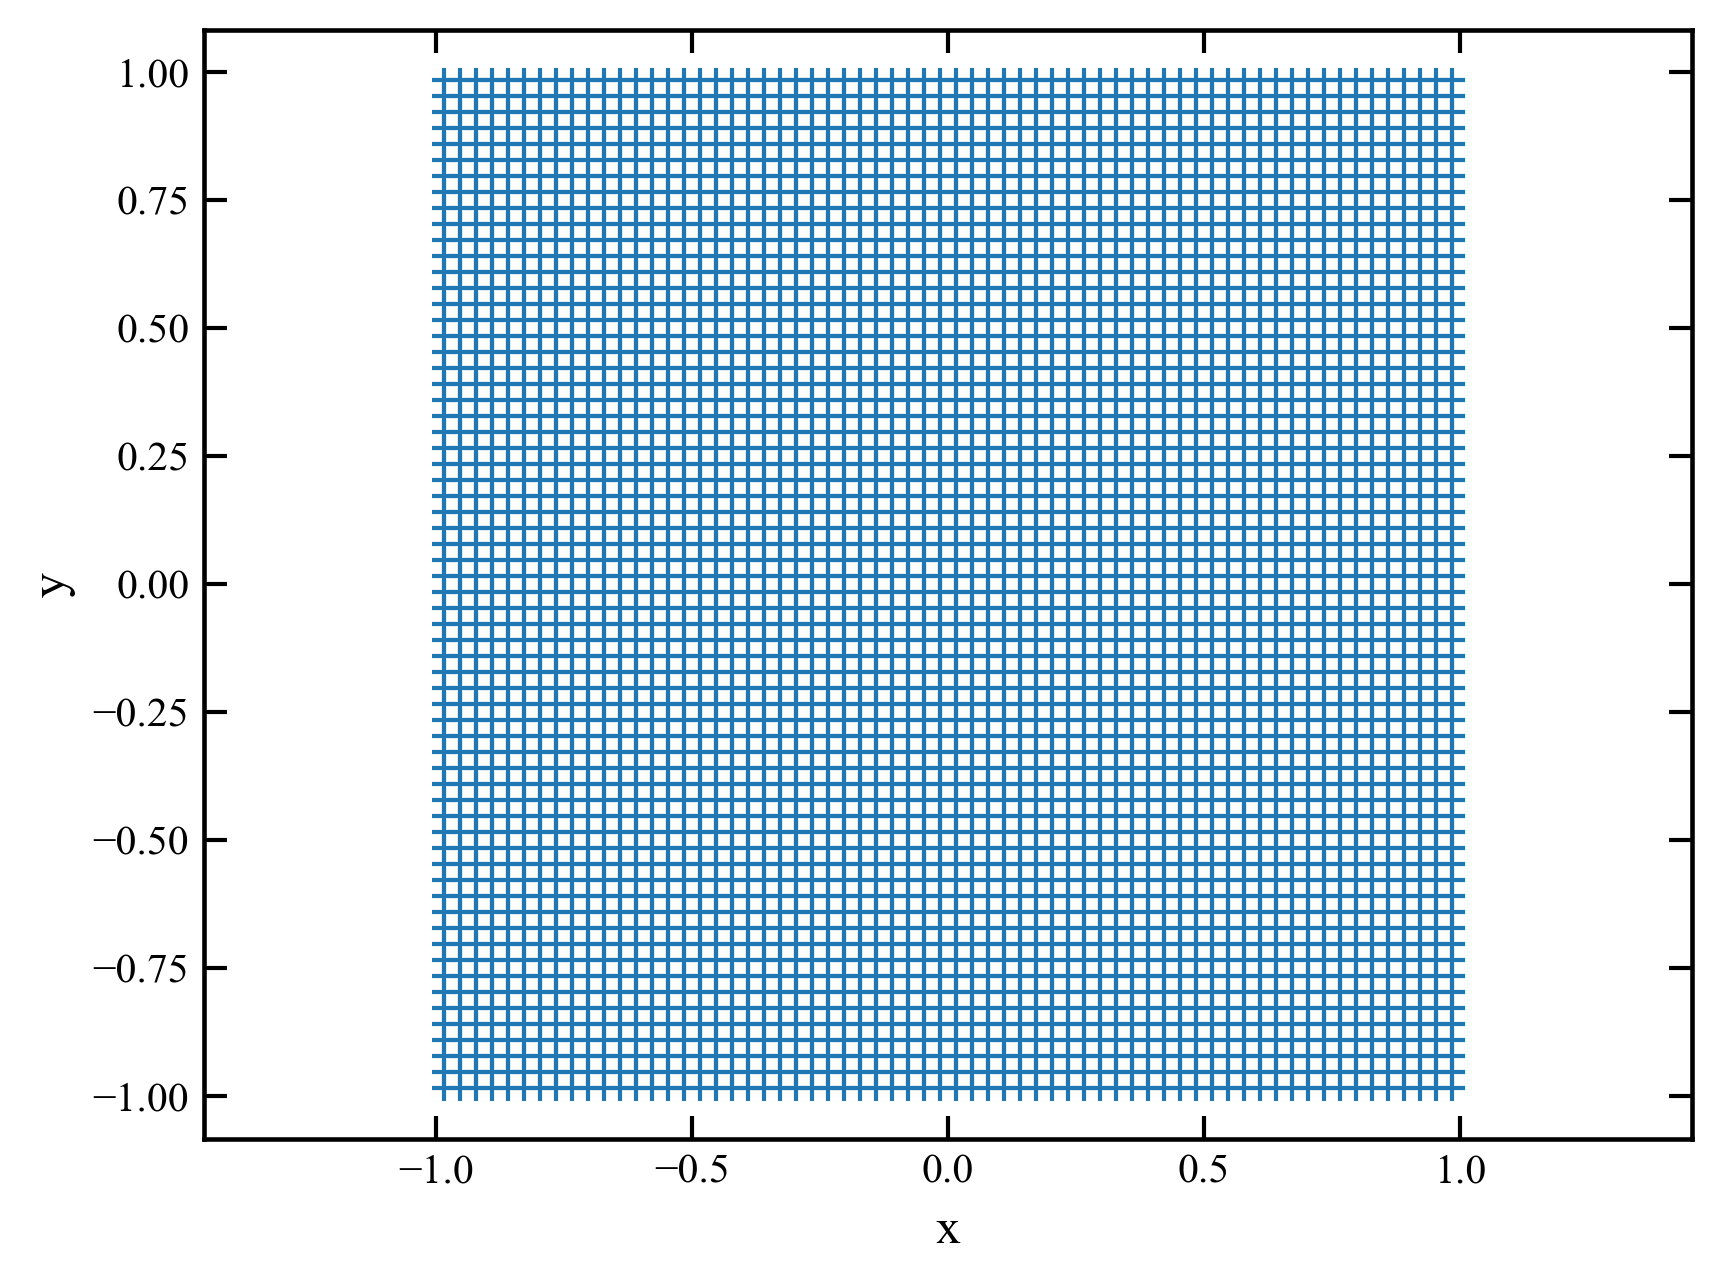

In [33]:
grid = make_uniform_grid([64, 64], [2,2]) # creates a uniform grid of 8x8 points in a rectangle of size 2x1
plt.plot(grid.x, grid.y, '+')
plt.axis('equal')
plt.xlabel('x')
plt.ylabel('y')

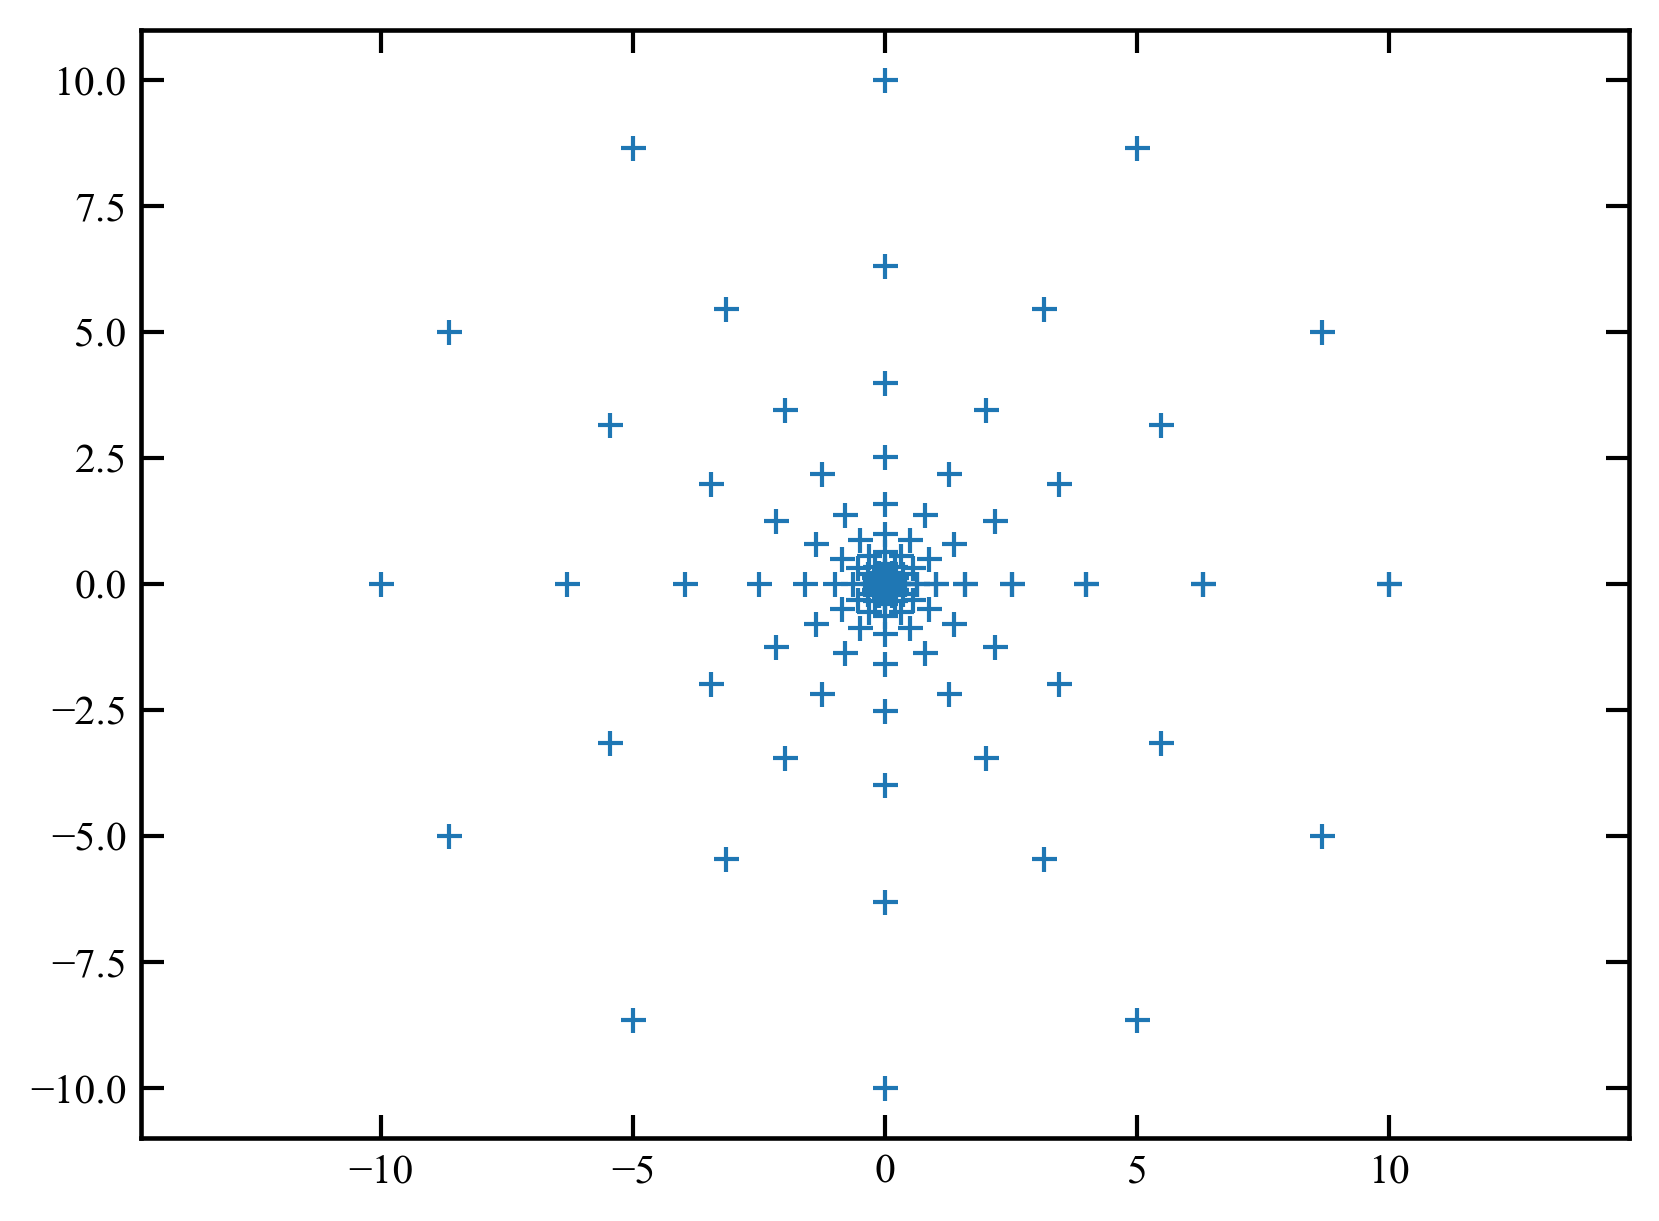

In [34]:
# Try creating a grid in polar coordinates
r = np.logspace(-1,1,11)
theta = np.linspace(0, 2*np.pi, 13)
coords = SeparatedCoords((r, theta))

polar_grid = PolarGrid(coords)
cart_grid = polar_grid.as_('cartesian')
plt.figure()
#plt.plot(polar_grid.r, polar_grid.theta, '+')
plt.axis('equal')   
plt.plot(cart_grid.x, cart_grid.y, '+')

this maybe useful for later when we want to seperate by spatial frequency in Fourier Space...

## The Field

The field is a sampled function on a grid

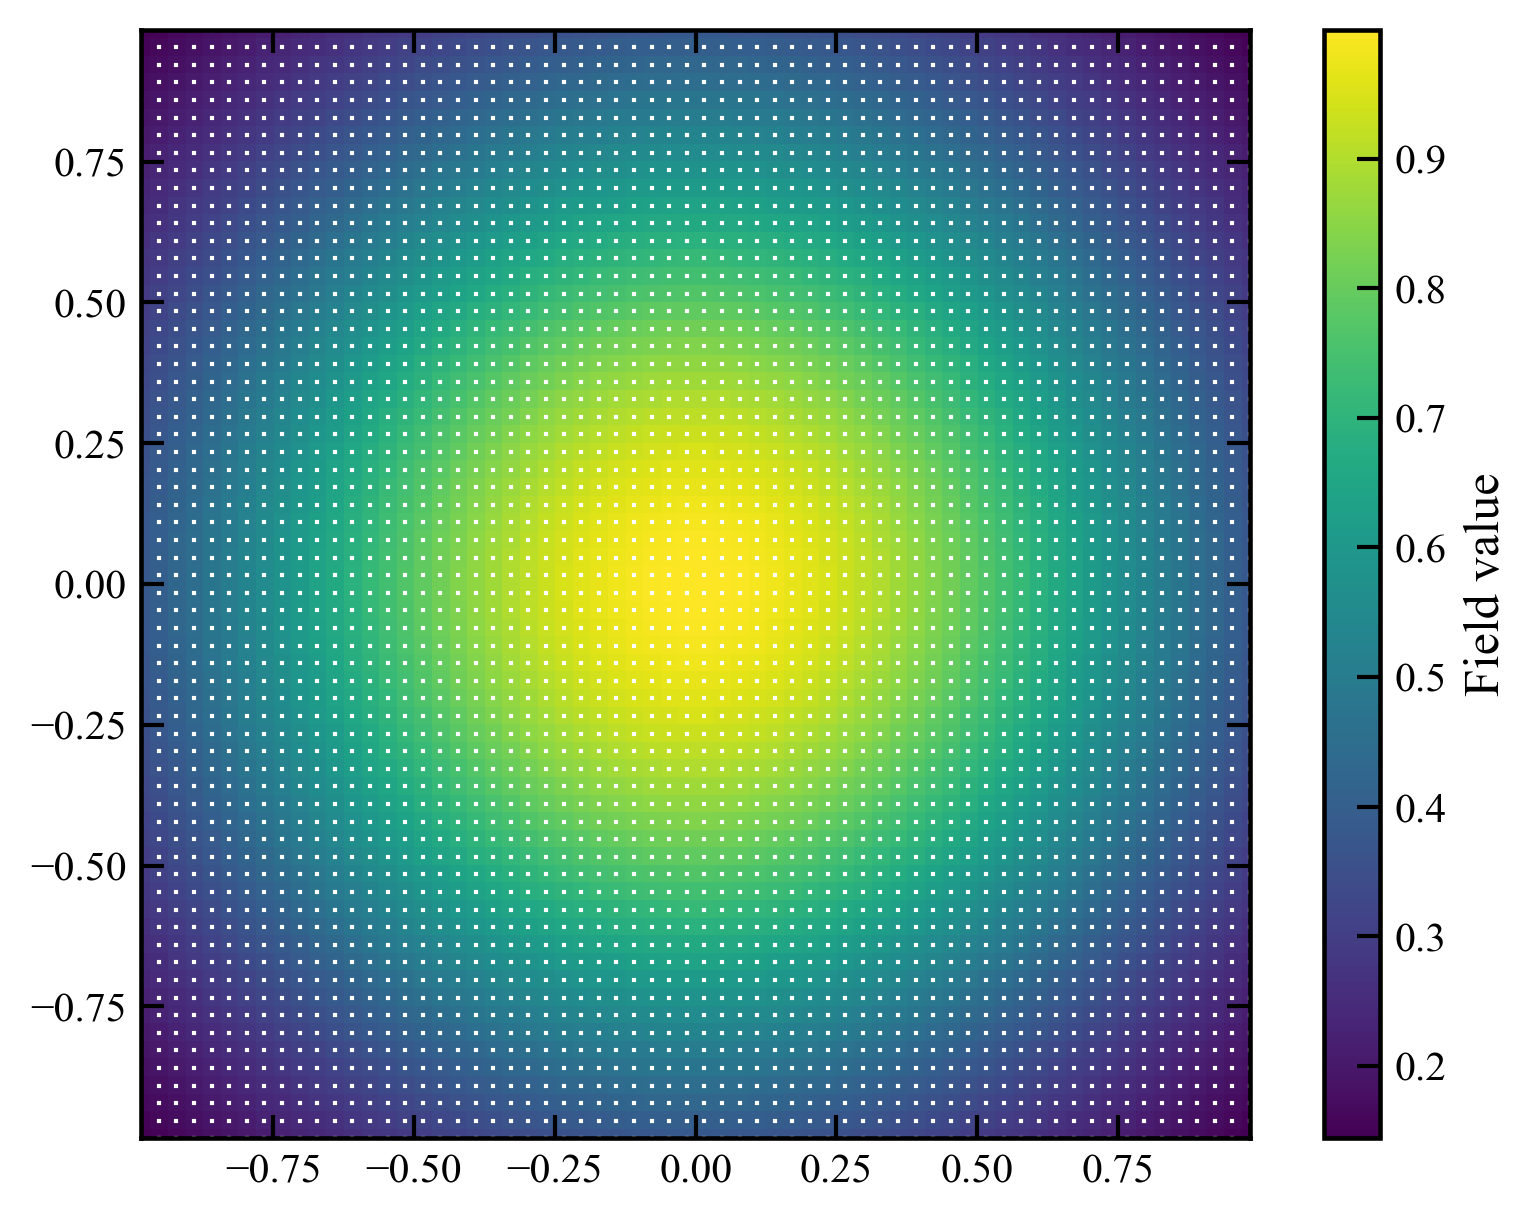

In [35]:
vals = np.exp(-(grid.x**2 + grid.y**2)) # 2 D Gaussian field
field = Field(vals, grid)

imshow_field(field, cmap='viridis')
# overlay the grid points on top of the field
plt.plot(grid.x, grid.y, '+', color='white', markersize=1)
plt.colorbar(label='Field value')

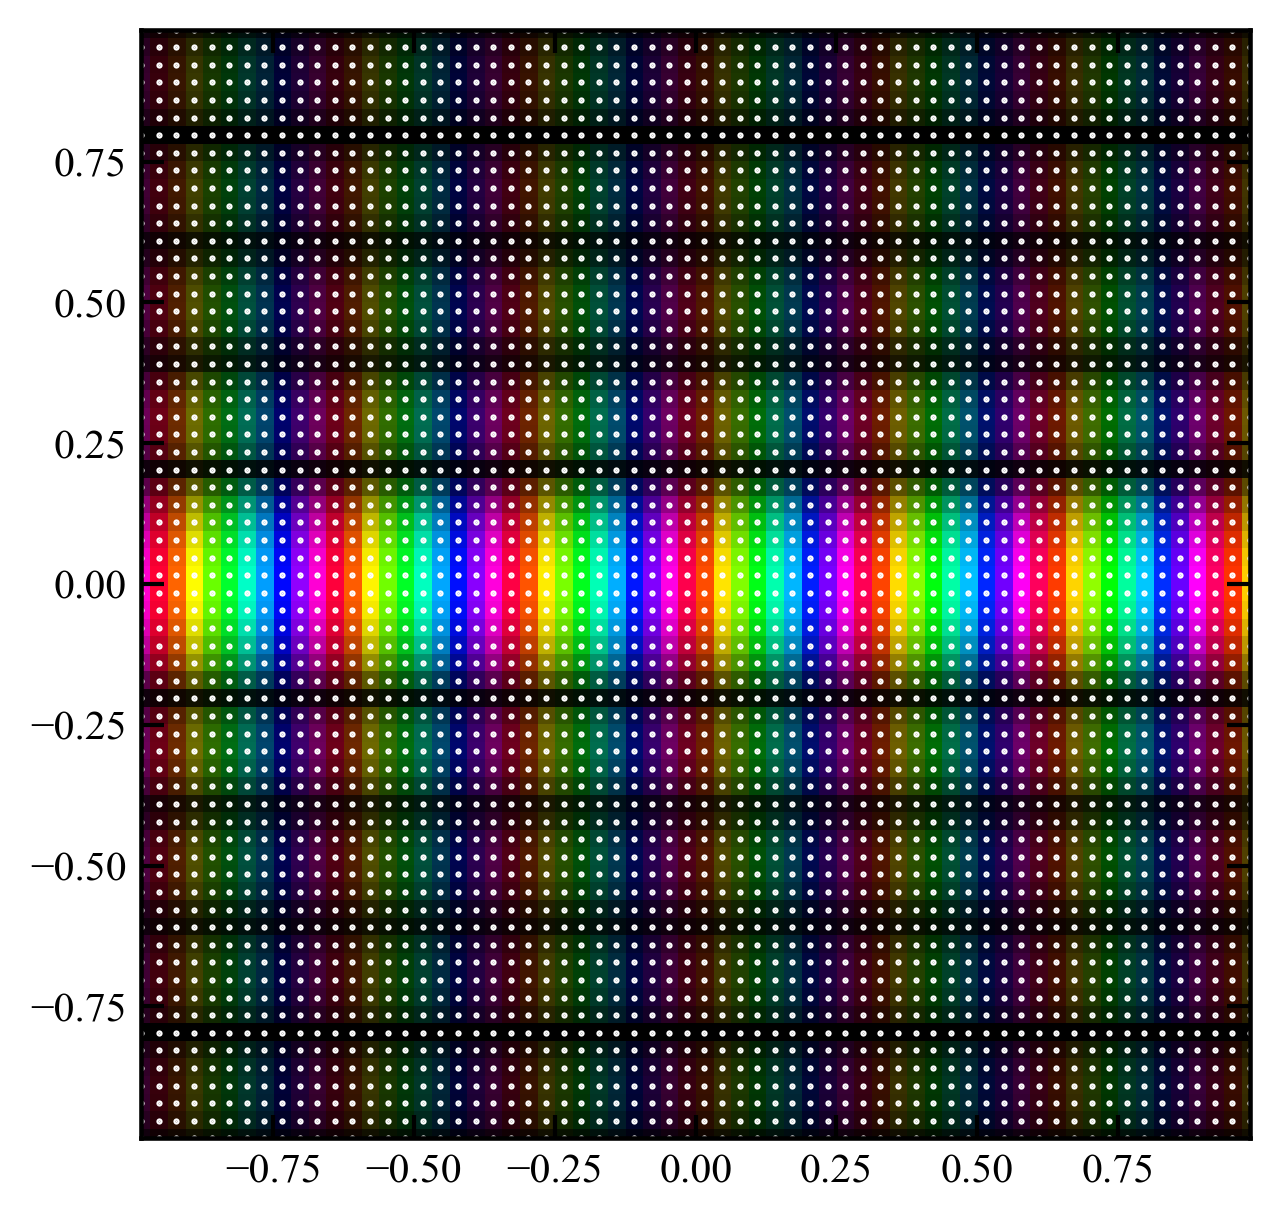

In [36]:
# Also support for complex fields 
complex_vals = np.exp(1j * grid.x * 20) * np.sqrt(np.abs(np.sinc(5*grid.y)))
complex_field = Field(complex_vals, grid)

imshow_field(complex_field)
plt.scatter(grid.x, grid.y, marker = '.', color='white', s=1)


Great, now we will create a field mask (but we will revisit full masking later):    

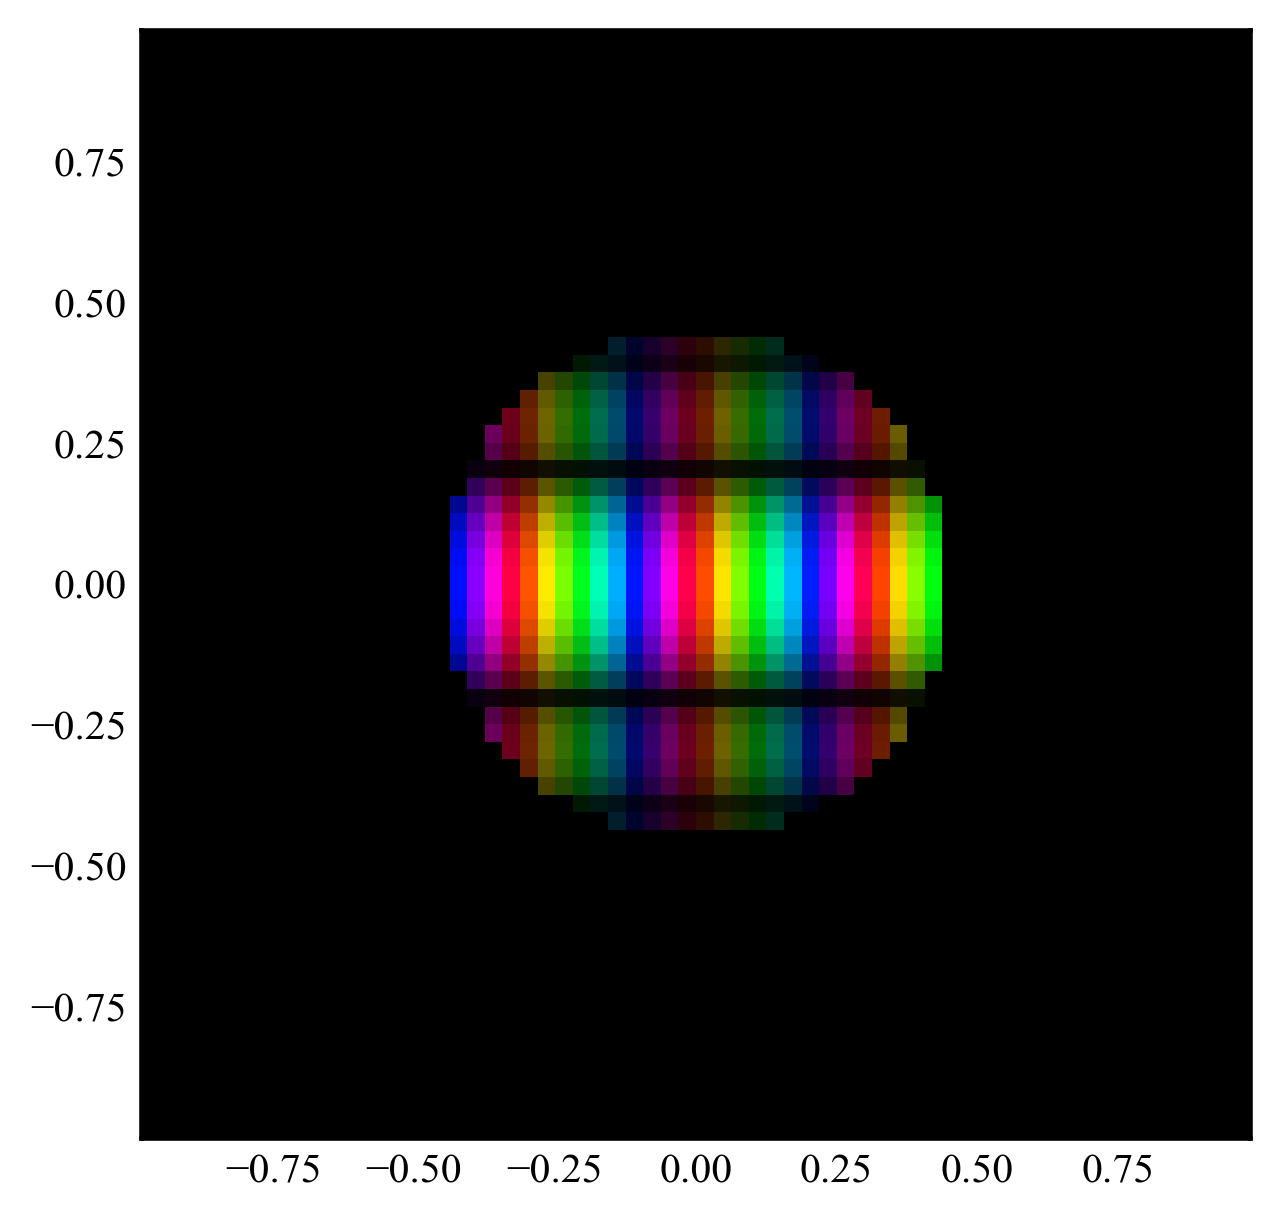

In [37]:
mask=make_circular_aperture(0.9)(grid)

imshow_field(complex_field, mask = mask, cmap='gray')

## Aperture Generation

In [42]:
# in case you can't use make_subaru_aperture 
print(hcipy.__version__)

0.6.0


In [41]:
# First make a grid that you will use to make a telescope aperture # this is normalized (so the diameter of the pupil is 1) set diameter and unnormalize to get physical size
subaru_pupil_grid = make_pupil_grid(128)
subaru_aperture = hcipy.aperture.make_subaru_aperture(normalized=True)

aperture_field = subaru_aperture(subaru_pupil_grid)
imshow_field(aperture_field)
plt.show()

TypeError: make_subaru_aperture() got an unexpected keyword argument 'normalized'

Great! 
We've made the subaru pupil!

# Wavefronts

In HCIpy, the wavefronts are monochromatic (i.e. at one wavelength) it consists of an electric field (an HCIpy field) and a wavelength. Multiple wavelengths need their own wavefronts. We want to propgate the the wavefront from the pupil plane to the focal plane. Like the pupil plane, we need to generate a grid on which the focal plane wil be sampled. 

In [10]:
wavefront = Wavefront(aperture_field, wavelength=1)

NameError: name 'aperture_field' is not defined

In [11]:
focal_grid = make_focal_grid(8, 16)

In [12]:
propagator = FraunhoferPropagator(subaru_pupil_grid, focal_grid)


image = propagator.forward(wavefront)

Quick note about Fraunhofer propagation. This is the far field limit of fresnel diffraction where the observation plane is far enough away that the field is the FT of the aperture field.

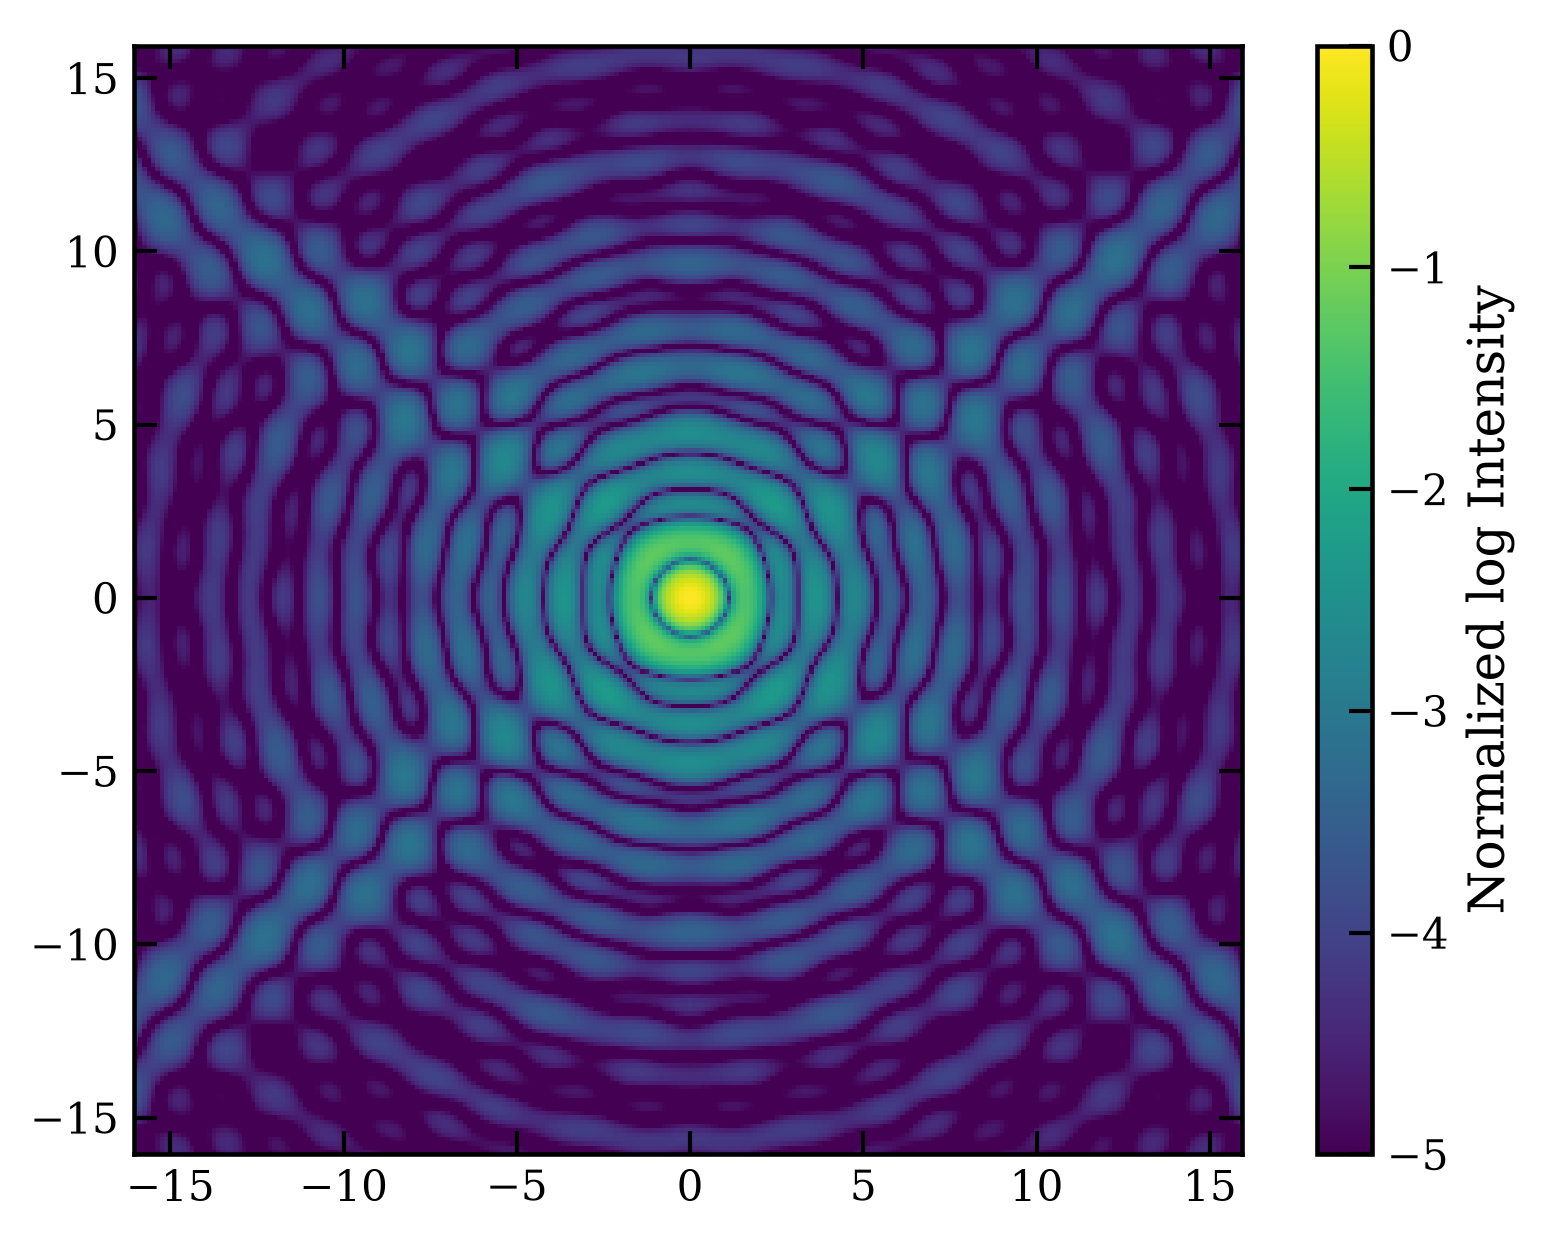

In [13]:
# Plot the image -- using logspace for the color scale to better visualize the dynamic range

imshow_field(np.log10(np.abs(image.intensity/ image.intensity.max())), cmap='viridis', vmin=-5, vmax=0)
plt.colorbar(label = 'Normalized log Intensity')

Compare this to the SCExAO psf -- looks okay! ![scexaopsf](scexao_psf_example.jpg)

We can also plot things like physical quantities. Find the intensity pattern of the Subaru aperture after a free space propagation for 15 meters (focal distance of Subaru).


Text(0, 0.5, 'y [m]')

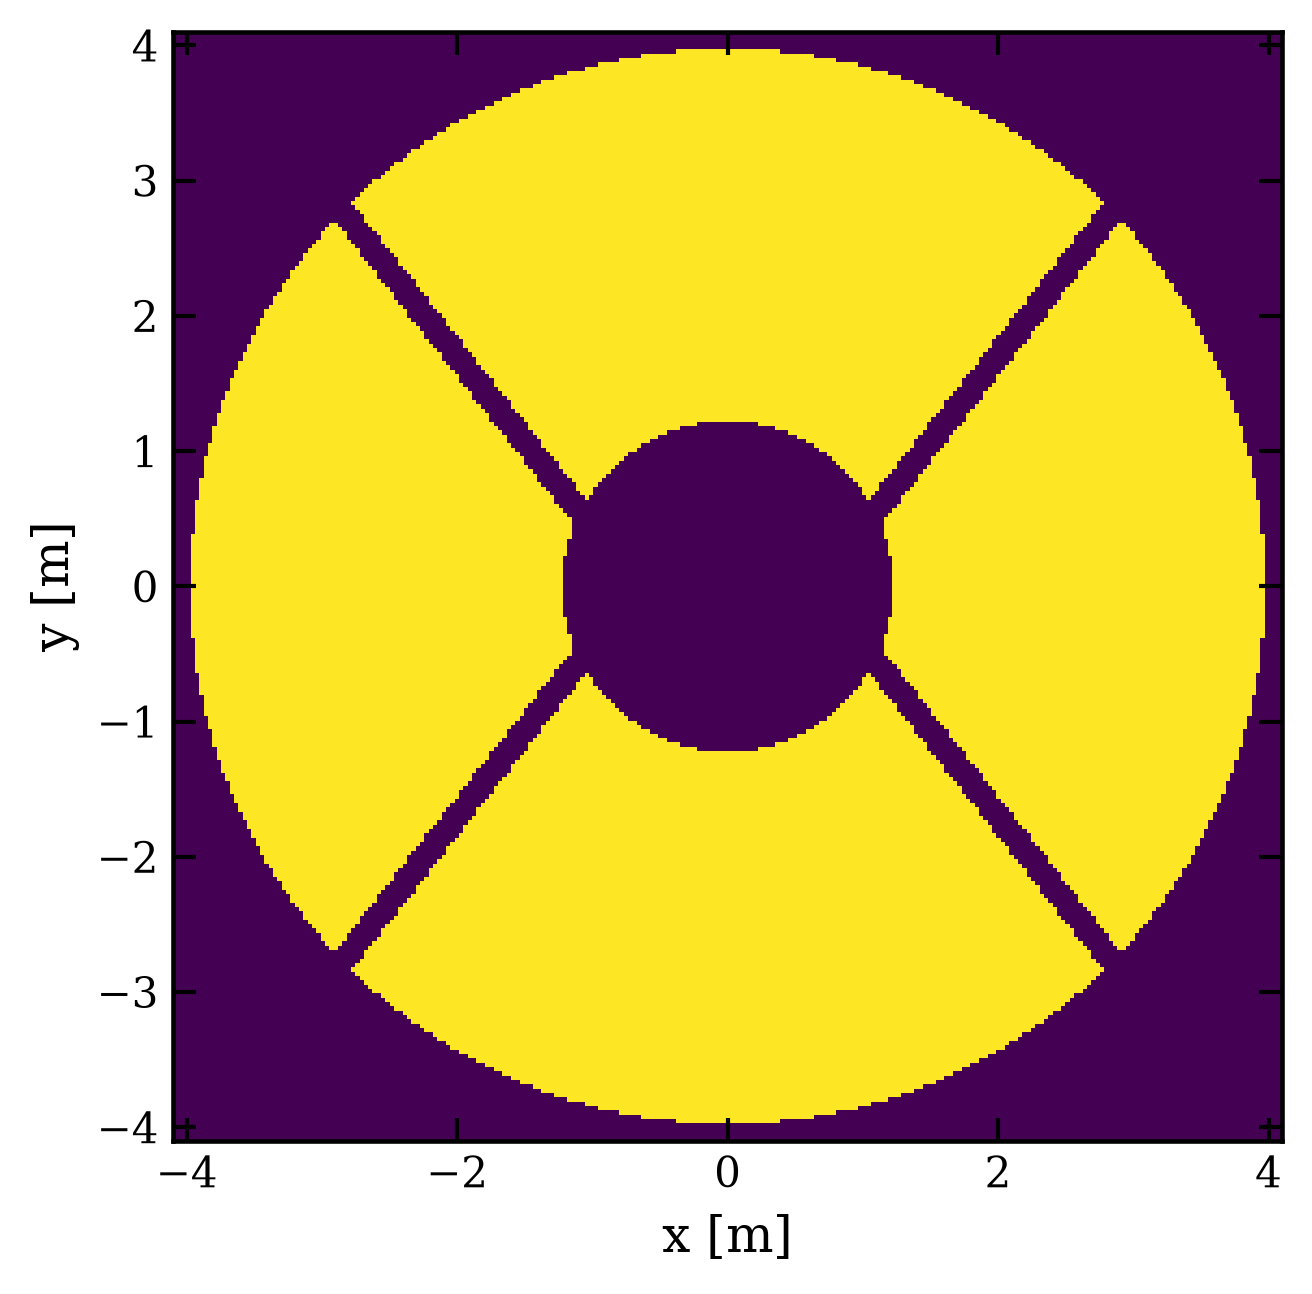

In [14]:
subaru_physical_pupil_grid = make_pupil_grid(256, diameter=8.2) # 8 m diameter pupil
subaru_physical_aperture = make_subaru_aperture(normalized=False)

physical_aperture_field = subaru_physical_aperture(subaru_physical_pupil_grid)
imshow_field(physical_aperture_field)
plt.xlabel('x [m]')
plt.ylabel('y [m]')


In [15]:
# Redo the focal grid 
physical_focal_grid = make_focal_grid(q = 16, num_airy = 4, pupil_diameter=8.2, focal_length=15, reference_wavelength=500e-9) # 8 m diameter pupil, 15 m focal length, 500 nm wavelength

In [22]:
physical_propagator = FraunhoferPropagator(subaru_physical_pupil_grid, physical_focal_grid)
physical_wavefront = Wavefront(physical_aperture_field, wavelength=500e-9) # 500 nm wavelength
physical_image = physical_propagator.forward(physical_wavefront)

Text(0, 0.5, 'y [m]')

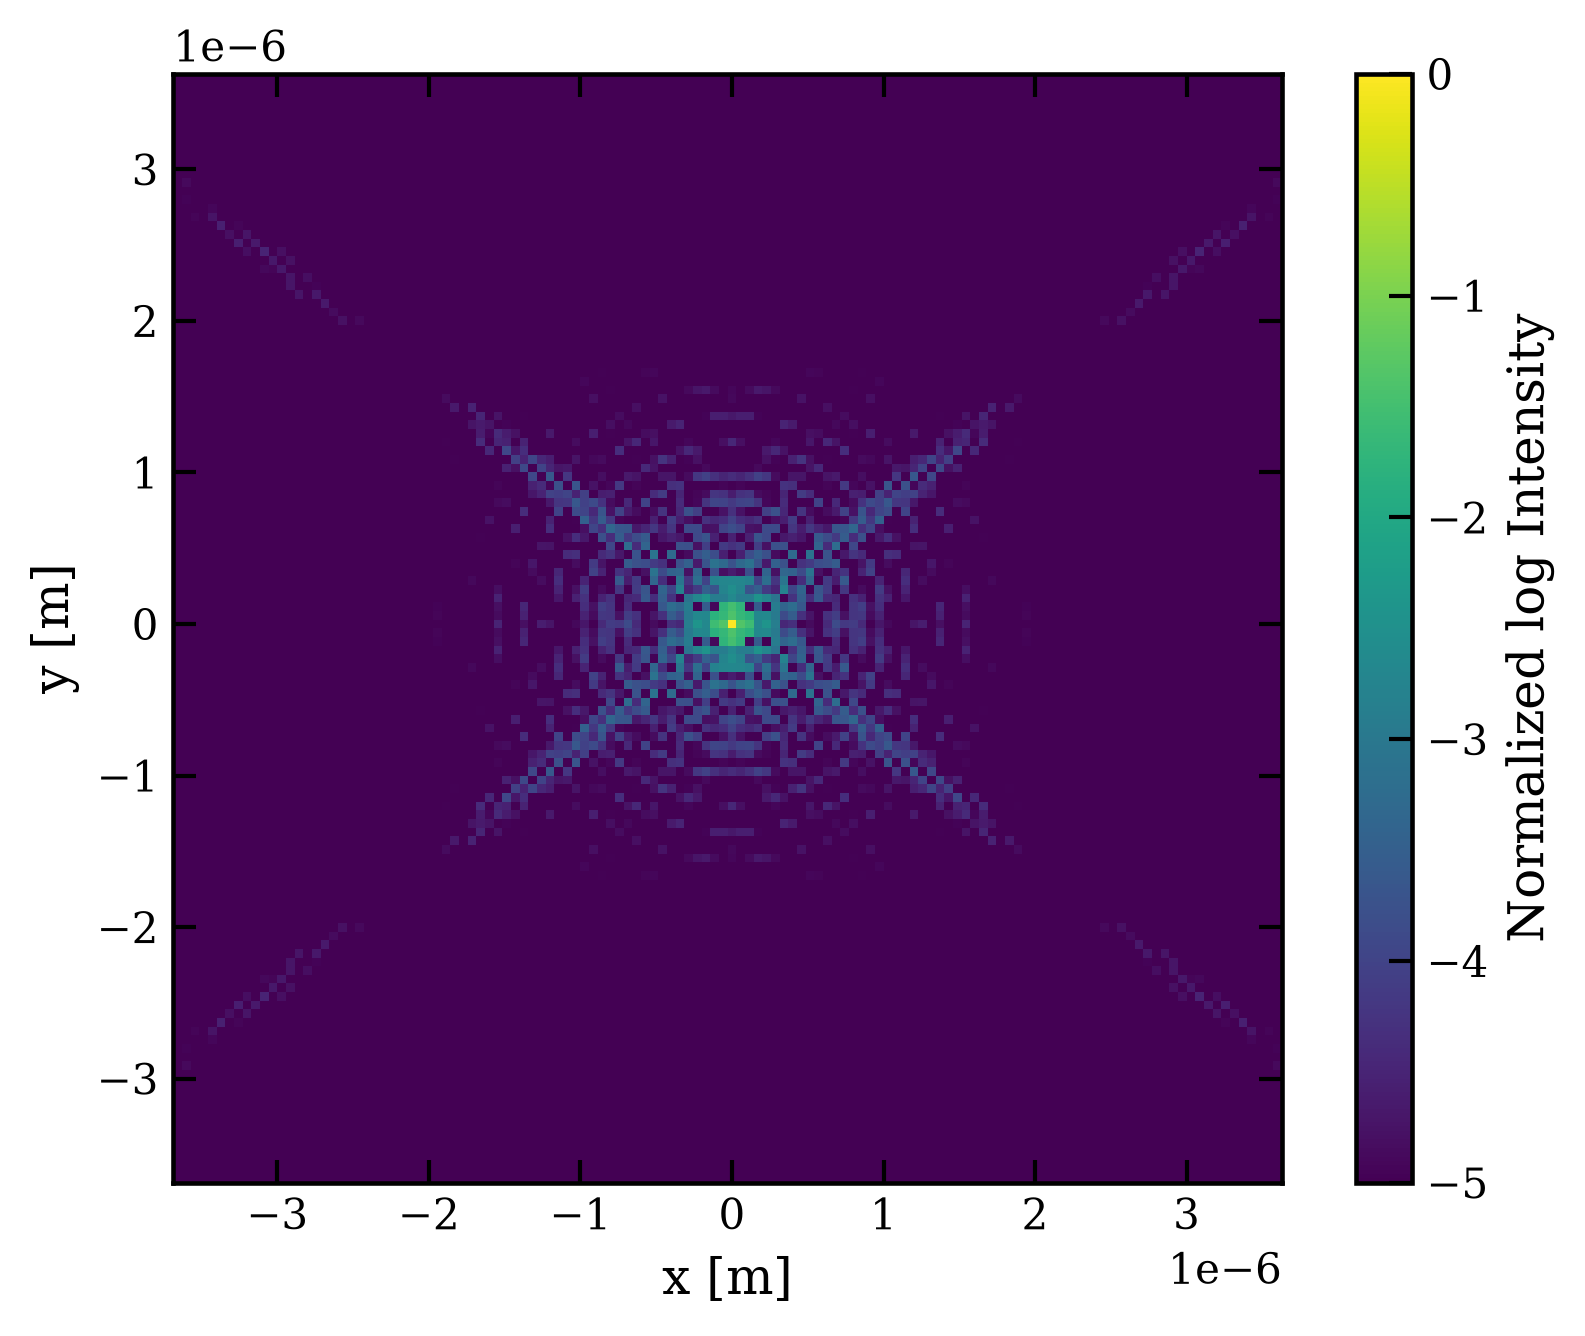

In [23]:
imshow_field(np.log10(np.abs(physical_image.intensity/ physical_image.intensity.max())), cmap='viridis', vmin=-5, vmax=0)
plt.colorbar(label = 'Normalized log Intensity')
plt.xlabel('x [m]')
plt.ylabel('y [m]')

Looks pretty reasonable - you can also add detector noise as follows:

/tmp/ipykernel_306067/3695029112.py:11: RuntimeWarning: divide by zero encountered in log10
  imshow_field(np.log10(image), vmax=np.log10(image).max(), vmin=0)


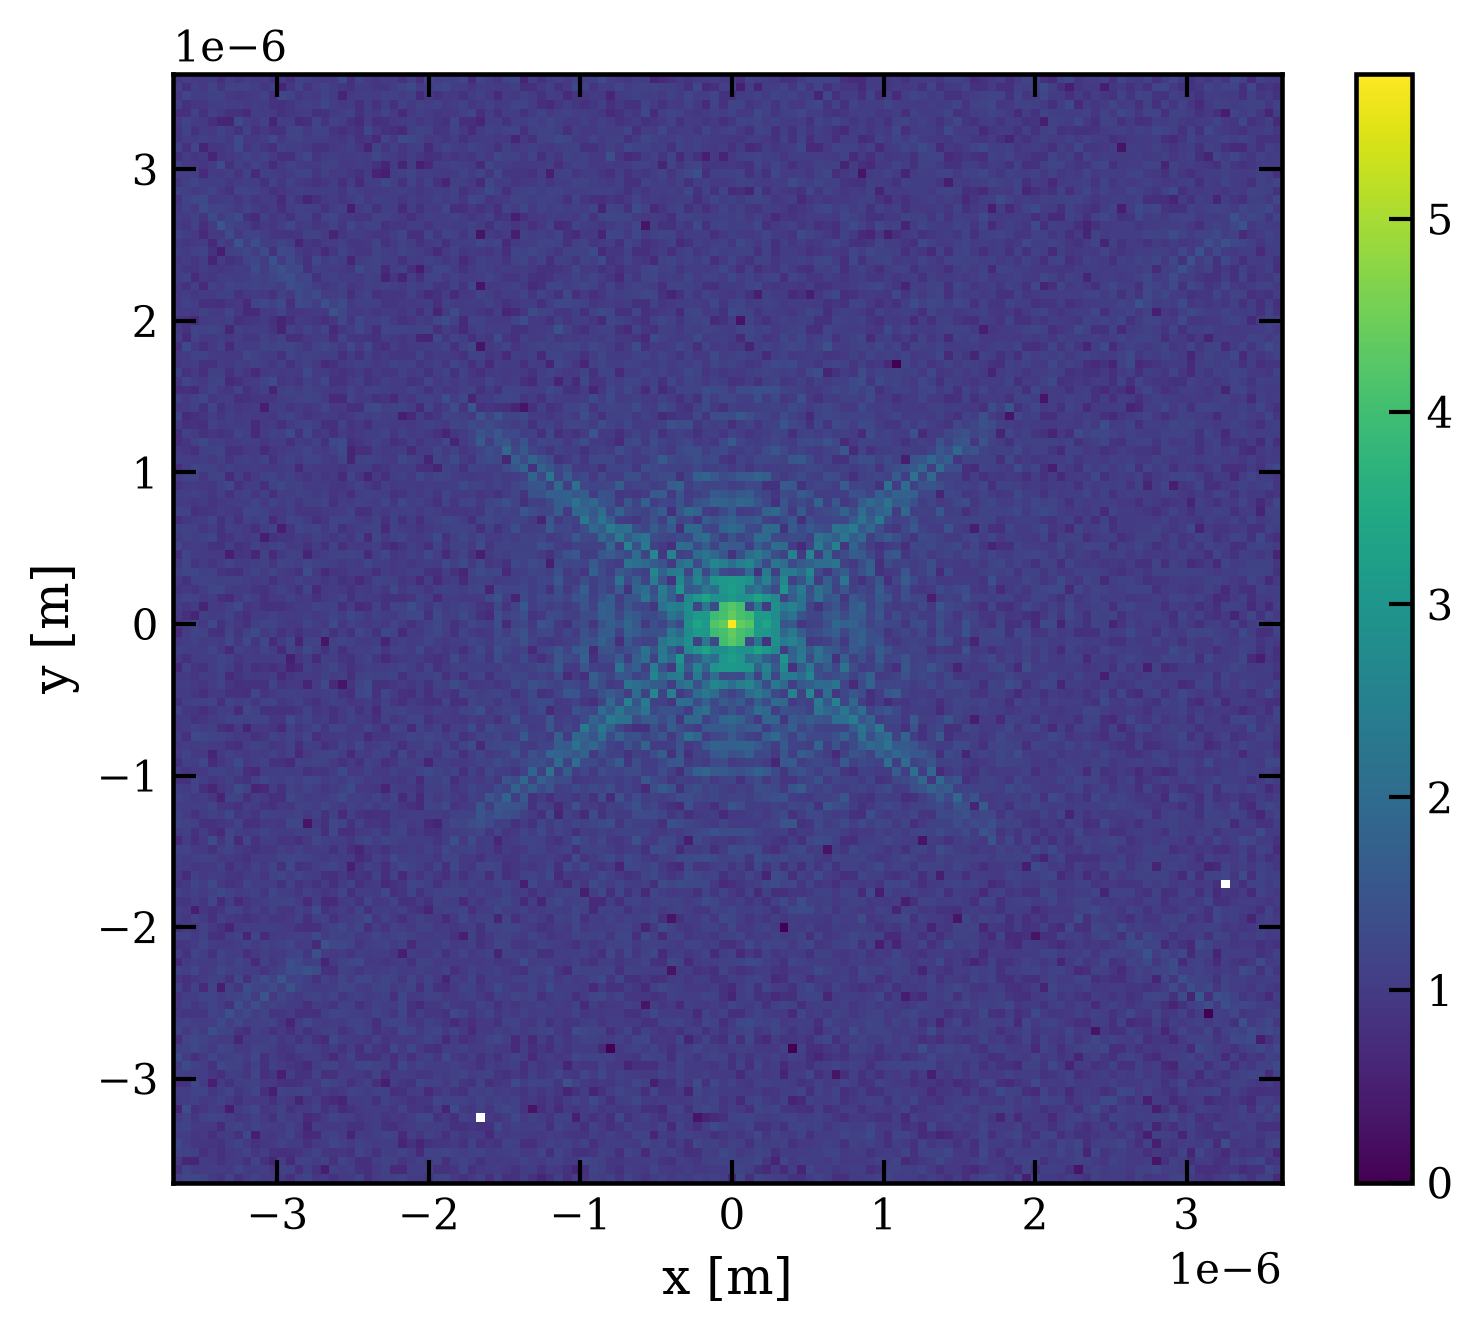

In [24]:
flat_field = 0.01
dark = 10
detector = NoisyDetector(physical_focal_grid, dark_current_rate=dark, flat_field=flat_field)

physical_wavefront.total_power = 1e6
img = physical_propagator.forward(physical_wavefront)

detector.integrate(img, 1.0) # integrate for 1 second
image = detector.read_out()

imshow_field(np.log10(image), vmax=np.log10(image).max(), vmin=0)
plt.colorbar()
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.show()

In [25]:
# Introduce a random aberration to the wavefront and see how it affects the image
physical_ncpa_ptv = 200e-9  # 100 nm peak-to-valley
physical_ncpa = SurfaceAberration(
    subaru_physical_pupil_grid,
    ptv=physical_ncpa_ptv,
    diameter=8.2,
    aperture=physical_aperture_field,
    exponent=-2.5
)

physical_propagator = FraunhoferPropagator(subaru_physical_pupil_grid, physical_focal_grid)
physical_wavefront = Wavefront(physical_aperture_field, wavelength=500e-9) # 500 nm wavelength
physical_image_ncpa = physical_propagator.forward(physical_ncpa(physical_wavefront))


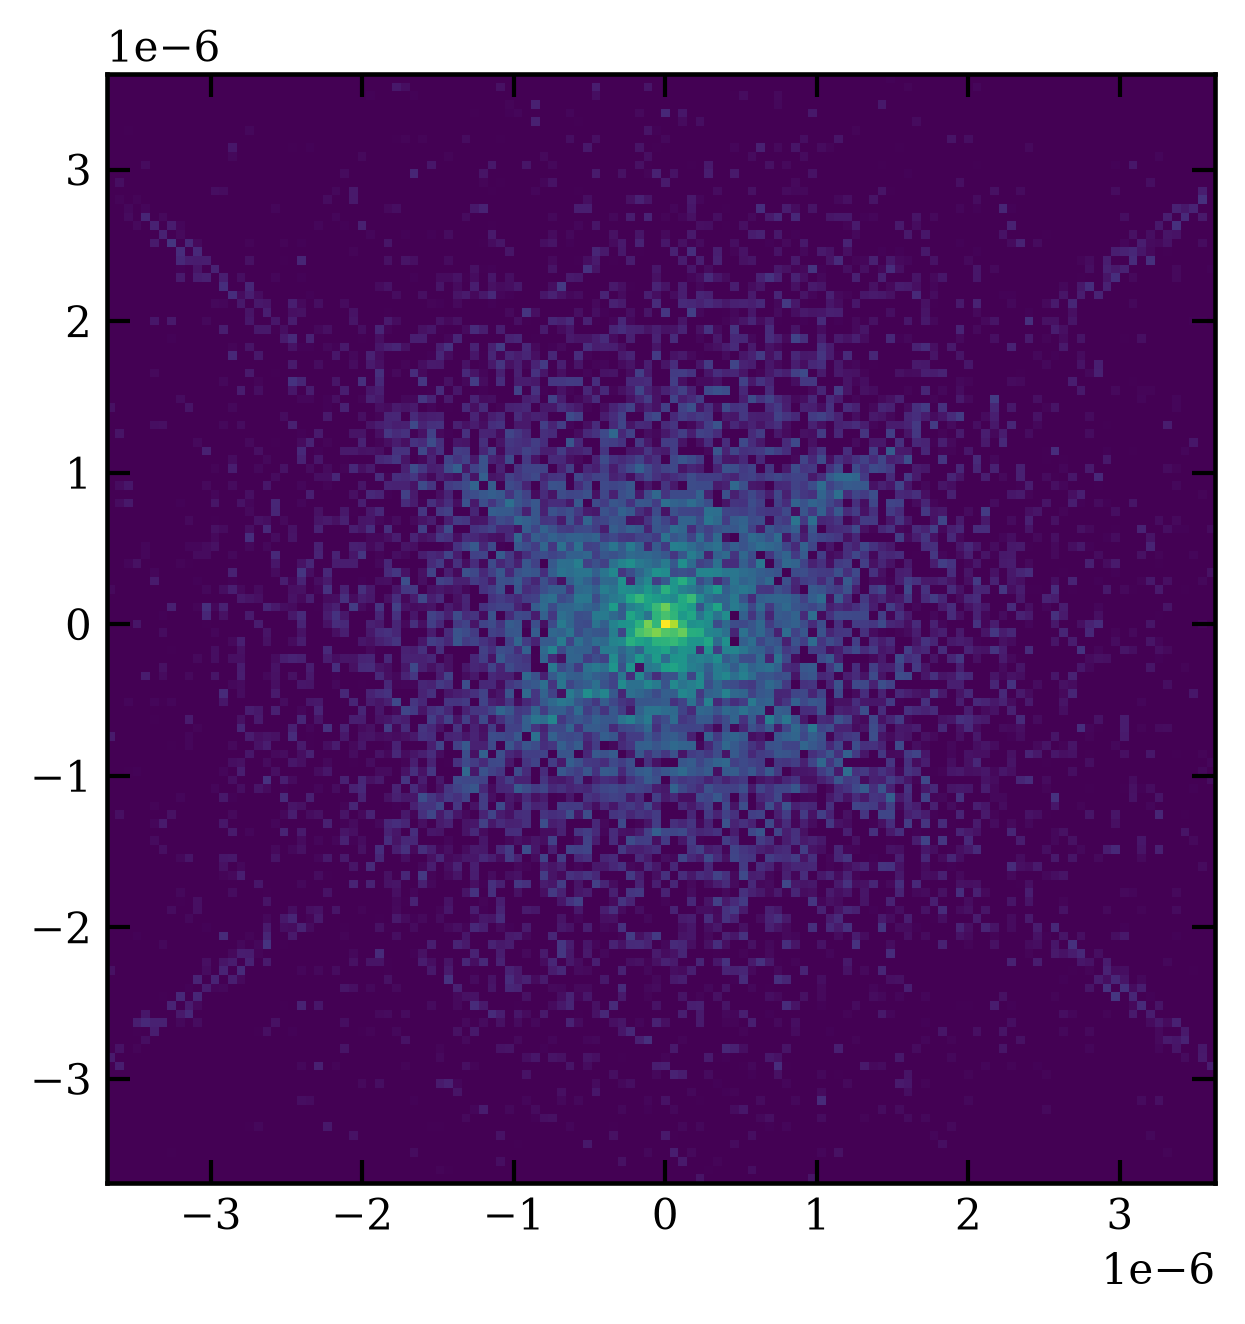

In [26]:
imshow_field(np.log10(np.abs(physical_image_ncpa.intensity/ physical_image_ncpa.intensity.max())), cmap='viridis', vmin=-5, vmax=0)

Text(0, 0.5, 'y [$\\lambda/D$]')

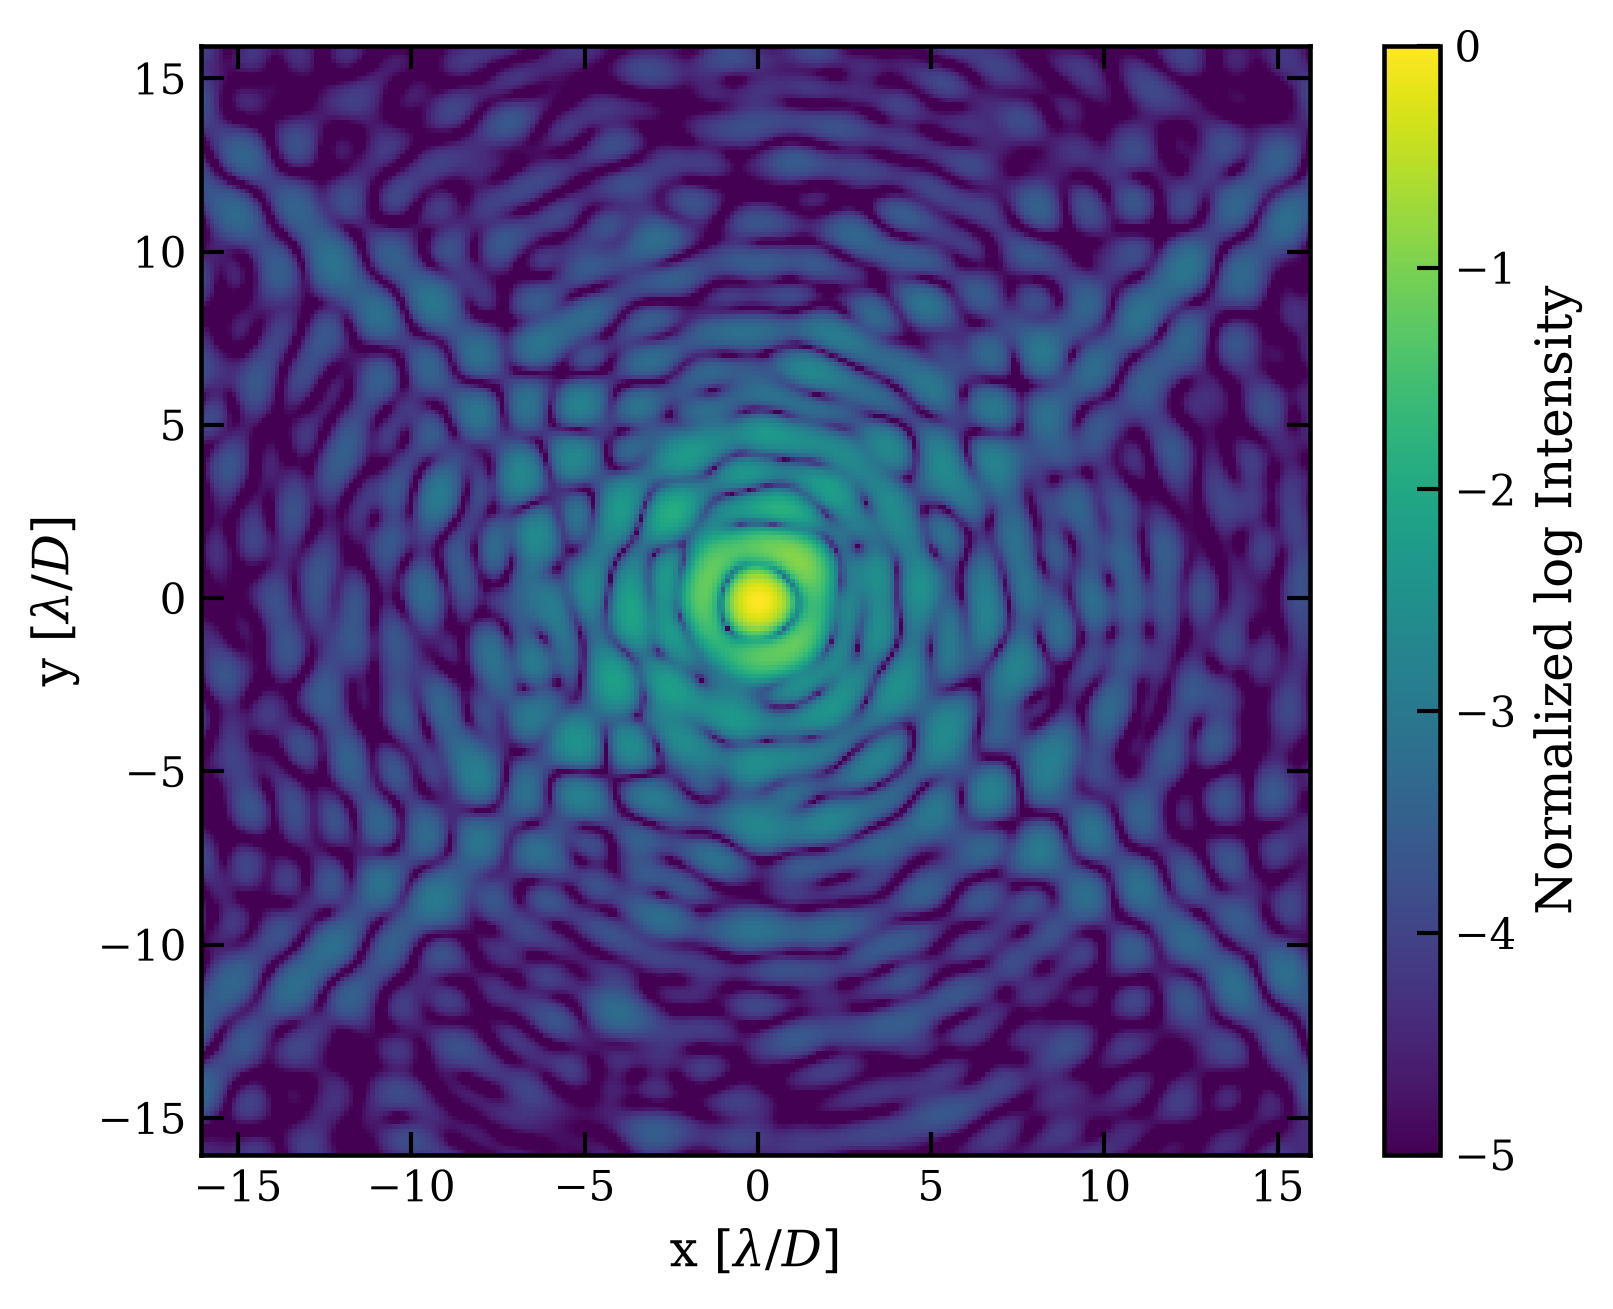

In [31]:
# Now try it again in lambda/D space 
ncpa_ptv = 0.2 # waves 
ncpa = SurfaceAberration(
    subaru_pupil_grid,
    ptv=ncpa_ptv,
    diameter=1.0,
    aperture=aperture_field,
    exponent=-2.5
)

image_ncpa = propagator.forward(ncpa(wavefront))
imshow_field(np.log10(np.abs(image_ncpa.intensity/ image_ncpa.intensity.max())), cmap='viridis', vmin=-5, vmax=0)
plt.colorbar(label = 'Normalized log Intensity')
plt.xlabel(rf'x [$\lambda/D$]')
plt.ylabel(rf'y [$\lambda/D$]')


# Introducing the Atmosphere and AO

grid = make_un